In [17]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB4
from keras.saving import register_keras_serializable
import numpy as np

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Full Deepfake Detector
# ─────────────────────────────────────────────────────────────────────────────
def build_deepfake_detector(
    num_frames: int   = 16,
    img_size:   int   = 224,
    d_model:    int   = 512,
    num_heads:  int   = 8,
    ff_dim:     int   = 1024,
    num_transformer_layers: int   = 4,
    dropout_rate:           float = 0.3,
    num_classes:            int   = 1,
):
    """
    Returns (model, backbone).

    Per-frame data flow:
    ┌─ Path A (trainable) ──────────────────────────────────────────────────┐
    │  EfficientNetB4 (pooling=avg)  →  eff_feat  (1792,)                  │
    └───────────────────────────────────────────────────────────────────────┘
                                    concat  →  (3584,)
    ┌─ Path B (stop_gradient) ──────────────────────────────────────────────┐
    │  GradCAMExtractor  →  cam_feat  (1792,)  →  tf.stop_gradient()       │
    └───────────────────────────────────────────────────────────────────────┘
                                    ↓
                          Dense  →  (d_model,)
                          PositionalEncoding
                          TemporalTransformer × N
                          head  →  sigmoid output
    """

    # ── Path A: Main trainable backbone (global avg pooling)
    backbone = EfficientNetB4(
        include_top = False,
        weights     = "imagenet",
        input_shape = (img_size, img_size, 3),
        pooling     = "avg",        # → (1792,) per frame — same as original
    )
    backbone.trainable = False      # frozen in phase 1, partially unfrozen in phase 2

    # ── Path B: Grad-CAM extractor (always frozen, stop_gradient on output)
    gradcam_extractor = GradCAMExtractor(img_size=img_size, name="gradcam_extractor")

    # ── Input
    frame_input = layers.Input(
        shape=(num_frames, img_size, img_size, 3), name="frames"
    )

    # ── 1. Path A — EfficientNet features  (B, T, 1792)
    eff_feat = layers.TimeDistributed(
        backbone, name="efficientnet_td"
    )(frame_input)

    # ── 2. Path B — Grad-CAM features  (B, T, 1792)  [stop_gradient applied inside]
    cam_feat = gradcam_extractor(frame_input)   # (B, T, 1792)

    # ── 3. Concatenate both  →  (B, T, 3584)
    combined = layers.Concatenate(axis=-1, name="eff_cam_concat")([eff_feat, cam_feat])

    # ── 4. Project to d_model  →  (B, T, d_model)
    x = layers.TimeDistributed(
        layers.Dense(d_model, activation="relu"), name="projection"
    )(combined)
    x = layers.TimeDistributed(
        layers.LayerNormalization(), name="proj_norm"
    )(x)

    # ── 5. Positional encoding
    x = PositionalEncoding(num_frames, d_model, name="pos_encoding")(x)

    # ── 6. Temporal Transformer
    for i in range(num_transformer_layers):
        x = TemporalTransformerBlock(
            d_model=d_model, num_heads=num_heads,
            ff_dim=ff_dim,   dropout_rate=dropout_rate,
            name=f"transformer_{i}",
        )(x)

    # ── 7. Aggregate
    avg = layers.GlobalAveragePooling1D(name="avg_pool")(x)
    mx  = layers.GlobalMaxPooling1D(name="max_pool")(x)
    x   = layers.Concatenate(name="concat_pool")([avg, mx])

    # ── 8. Classification head
    x = layers.Dense(256, activation="gelu", name="head_fc")(x)
    x = layers.Dropout(dropout_rate, name="head_drop")(x)

    if num_classes == 1:
        output = layers.Dense(1, activation="sigmoid", name="output")(x)
    else:
        output = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = Model(inputs=frame_input, outputs=output,
                  name="DeepfakeDetector_TrueGradCAM")
    return model, backbone

In [19]:
model,backbone = build_deepfake_detector()

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Positional Encoding
# ─────────────────────────────────────────────────────────────────────────────
@register_keras_serializable()
class PositionalEncoding(layers.Layer):
    def __init__(self, seq_len: int, d_model: int, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.d_model = d_model
        self.pos_encoding = self._build(seq_len, d_model)

    @staticmethod
    def _build(seq_len, d_model):
        positions = np.arange(seq_len)[:, np.newaxis]
        dims      = np.arange(d_model)[np.newaxis, :]
        angles    = positions / np.power(10000, (2 * (dims // 2)) / d_model)
        angles[:, 0::2] = np.sin(angles[:, 0::2])
        angles[:, 1::2] = np.cos(angles[:, 1::2])
        return tf.cast(angles[np.newaxis], tf.float32)

    def call(self, x):
        return x + self.pos_encoding[:, : tf.shape(x)[1], :]

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"seq_len": self.seq_len, "d_model": self.d_model})
        return cfg

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# Transformer Encoder Block
# ─────────────────────────────────────────────────────────────────────────────
@register_keras_serializable()
class TemporalTransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model      = d_model
        self.num_heads    = num_heads
        self.ff_dim       = ff_dim
        self.dropout_rate = dropout_rate
        self.attn  = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout_rate)
        self.ffn   = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dropout(dropout_rate),
            layers.Dense(d_model),
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop  = layers.Dropout(dropout_rate)

    def call(self, x, training=False):
        attn_out = self.attn(x, x, training=training)
        x = self.norm1(x + self.drop(attn_out, training=training))
        x = self.norm2(x + self.drop(self.ffn(x, training=training), training=training))
        return x

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"d_model": self.d_model, "num_heads": self.num_heads,
                    "ff_dim": self.ff_dim, "dropout_rate": self.dropout_rate})
        return cfg

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# GradCAMExtractor
# ─────────────────────────────────────────────────────────────────────────────
@register_keras_serializable()
class GradCAMExtractor(layers.Layer):
    """
    Computes TRUE Grad-CAM features from EfficientNetB4's last conv block.

    KEY DESIGN: this layer owns a SEPARATE frozen backbone and does its OWN
    GradientTape internally.  The output is wrapped in tf.stop_gradient()
    so NO gradient from this path reaches the main training graph.

    This means:
      ✓ Transformer receives real Grad-CAM saliency values as input features
      ✓ Main EfficientNet backbone trains normally via its own gradient path
      ✓ No nested-tape conflicts → accuracy stays high

    How Grad-CAM is computed (standard algorithm):
      1. Forward pass → get last conv feature map F  (H, W, C)
      2. Forward pass → get class score s  (scalar)
      3. Gradients: α_c = GAP( ∂s/∂F_c )  — importance of channel c
      4. Weighted map: L = ReLU( Σ_c α_c * F_c )  — saliency map  (H, W)
      5. Pool L spatially → scalar saliency descriptor
         AND pool channel-weighted features → (C,) descriptor
      6. Concatenate both → final Grad-CAM feature vector
    """

    def __init__(self, img_size: int = 224, **kwargs):
        super().__init__(**kwargs)
        self.img_size = img_size

        # ── Frozen sub-backbone (no top, no pooling → keeps spatial map)
        self.cam_backbone = EfficientNetB4(
            include_top  = False,
            weights      = "imagenet",
            input_shape  = (img_size, img_size, 3),
            pooling      = None,
        )
        self.cam_backbone.trainable = False   # always frozen

        # A small 1×1 conv to produce a class-score logit from the feature map
        # This is also frozen/not updated by the main optimizer because
        # stop_gradient prevents gradients from flowing back to it.
        self.score_conv = layers.Conv2D(
            1, kernel_size=1, use_bias=True, name="cam_score_conv"
        )

    def _compute_gradcam_single(self, frame):
        """
        Compute Grad-CAM descriptor for a single frame.
        frame: (H, W, 3)  →  returns (C,) feature vector
        """
        frame = tf.expand_dims(frame, 0)          # (1, H, W, 3)

        with tf.GradientTape() as tape:
            # Watch the feature map (not input) for efficiency
            feat_map = self.cam_backbone(frame, training=False)  # (1, H', W', C)
            tape.watch(feat_map)
            score_map = self.score_conv(feat_map)                # (1, H', W', 1)
            score     = tf.reduce_mean(score_map)                # scalar

        # Gradients: ∂score/∂feat_map  →  (1, H', W', C)
        grads = tape.gradient(score, feat_map)

        # Channel importance weights: GAP over spatial dims  →  (1, 1, 1, C)
        alpha = tf.reduce_mean(grads, axis=[1, 2], keepdims=True)

        # Grad-CAM weighted features: elem-wise multiply then ReLU
        weighted = tf.nn.relu(feat_map * alpha)    # (1, H', W', C)

        # Pool to get a (C,) descriptor
        cam_feat = tf.reduce_mean(weighted, axis=[1, 2])   # (1, C)
        cam_feat = tf.squeeze(cam_feat, axis=0)             # (C,)

        # L2-normalise
        cam_feat = tf.math.l2_normalize(cam_feat, axis=-1)
        return cam_feat

    def call(self, frames_seq, training=False):
        """
        frames_seq: (B, T, H, W, 3)
        returns   : (B, T, C)  — Grad-CAM descriptors
                    wrapped in tf.stop_gradient so the main graph is clean
        """
        B = tf.shape(frames_seq)[0]
        T = tf.shape(frames_seq)[1]
        H = self.img_size
        W = self.img_size

        # Flatten (B, T, H, W, 3) → (B*T, H, W, 3) so we can vectorise
        frames_flat = tf.reshape(frames_seq, [B * T, H, W, 3])

        # Process each frame — use tf.vectorized_map for speed
        cam_flat = tf.vectorized_map(self._compute_gradcam_single, frames_flat)
        # cam_flat: (B*T, C)

        # Get C from cam_backbone output shape
        C = self.cam_backbone.output_shape[-1]
        cam_seq = tf.reshape(cam_flat, [B, T, C])   # (B, T, C)

        # ── CRITICAL: stop_gradient prevents this path from interfering
        #    with the main backbone's training gradients
        return tf.stop_gradient(cam_seq)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"img_size": self.img_size})
        return cfg

In [23]:
model = tf.keras.models.load_model(
    "/kaggle/input/models/pavanikonatala/final-gradcam-model/keras/default/1/best_model_gradcam (2).keras",
    custom_objects={
        "GradCAMExtractor": GradCAMExtractor,
        "PositionalEncoding": PositionalEncoding,
        "TemporalTransformerBlock": TemporalTransformerBlock
    },
    compile=False
)

print("✅ Model Loaded Successfully")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'gradcam_extractor', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer_0', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'transformer_1', however the layer

✅ Model Loaded Successfully


Model: "DeepfakeDetector_TrueGradCAM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ frames (InputLayer) │ (None, 16, 224,   │          0 │ -                 │
│                     │ 224, 3)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnet_td     │ (None, 16, 1792)  │ 17,673,823 │ frames[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gradcam_extractor   │ (None, 16, 1792)  │ 17,675,616 │ frames[0][0]      │
│ (GradCAMExtractor)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eff_cam_concat      │ (None, 16, 3584)  │          0 │ efficientnet_td[… │
│ (Concatenate)       │                   │            │ gradcam_extracto… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ projection          │ (None, 16, 512)   │  1,835,520 │ eff_cam_concat[0… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj_norm           │ (None, 16, 512)   │      1,024 │ projection[0][0]  │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_encoding        │ (None, 16, 512)   │          0 │ proj_norm[0][0]   │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_0       │ (None, 16, 512)   │  2,102,784 │ pos_encoding[0][… │
│ (TemporalTransform… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_1       │ (None, 16, 512)   │  2,102,784 │ transformer_0[0]… │
│ (TemporalTransform… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_2       │ (None, 16, 512)   │  2,102,784 │ transformer_1[0]… │
│ (TemporalTransform… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_3       │ (None, 16, 512)   │  2,102,784 │ transformer_2[0]… │
│ (TemporalTransform… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ avg_pool            │ (None, 512)       │          0 │ transformer_3[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pool            │ (None, 512)       │          0 │ transformer_3[0]… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_pool         │ (None, 1024)      │          0 │ avg_pool[0][0],   │
│ (Concatenate)       │                   │            │ max_pool[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_fc (Dense)     │ (None, 256)       │    262,400 │ concat_pool[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_drop (Dropout) │ (None, 256)       │          0 │ head_fc[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        257 │ head_drop[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 45,859,776 (174.94 MB)

 Trainable params: 10,512,130 (40.10 MB)

 Non-trainable params: 35,347,646 (134.84 MB)

In [24]:
!pip install ultralytics

In [25]:
import cv2
import os
from ultralytics import YOLO

def extract_faces_yolo(video_path,
                       output_folder,
                       model_path="/kaggle/input/models/pavanikonatala/yolo-face-model/other/default/1/yolov8n-face.pt",
                       frame_skip=10,
                       max_faces=30,
                       img_size=224):

    os.makedirs(output_folder, exist_ok=True)

    # Load YOLO model
    model = YOLO(model_path)
    # model = YOLO("https://github.com/derronqi/yolov8-face/releases/download/v1.0/yolov8n-face.pt")
    # model = YOLO("yolov5-face.pt")

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Could not open video.")
        return

    frame_count = 0
    saved_count = 0

    while True:
        ret, frame = cap.read()

        if not ret or saved_count >= max_faces:
            break

        if frame_count % frame_skip == 0:

            # Run YOLO inference
            results = model(frame, verbose=False)

            for r in results:
                boxes = r.boxes

                if boxes is not None:
                    for box in boxes:

                        # Get bounding box
                        x1, y1, x2, y2 = map(int, box.xyxy[0])

                        face = frame[y1:y2, x1:x2]

                        if face.size == 0:
                            continue

                        face = cv2.resize(face, (img_size, img_size))

                        save_path = os.path.join(
                            output_folder,
                            f"frame_{saved_count:02d}.jpg"
                        )

                        cv2.imwrite(save_path, face)
                        saved_count += 1
                        break

                break  # only first detection

        frame_count += 1

    cap.release()

    print("Extraction finished")
    print("Total faces saved:", saved_count)

In [26]:
import tensorflow as tf
import numpy as np

def compute_gradcam(model, frames, backbone, layer_name="top_conv"):
    
    # use EfficientNet backbone
    grad_model = tf.keras.models.Model(
        [backbone.inputs],
        [backbone.get_layer(layer_name).output, backbone.output]
    )

    frame = frames[0]   # pick one frame

    frame = tf.expand_dims(frame, axis=0)

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(frame)
        loss = tf.reduce_mean(predictions)

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap,0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

In [27]:
import cv2

def overlay_heatmap(frame, heatmap):

    heatmap = cv2.resize(heatmap, (frame.shape[1], frame.shape[0]))

    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    output = cv2.addWeighted(frame, 0.6, heatmap, 0.4, 0)

    return output

In [32]:
import matplotlib.pyplot as plt

def show_gradcam(folder_path):

    frames = []

    files = sorted([
        f for f in os.listdir(folder_path)
        if f.endswith((".jpg",".png",".jpeg"))
    ])[:16]

    for f in files:

        img = cv2.imread(os.path.join(folder_path,f))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # img = cv2.resize(img,(224,224))

        frames.append(img)

    frames = np.array(frames)

    # input_tensor = preprocess_input(frames.astype("float32"))
    input_tensor = np.expand_dims(frames,axis=0)

    pred = model.predict(input_tensor)

    prob = float(pred[0][0])

    print("\nFake probability:", prob)

    if prob > 0.5:
        print("Prediction: FAKE VIDEO")
    else:
        print("Prediction: REAL VIDEO")

    heatmap = compute_gradcam(model, input_tensor[0], backbone)

    result = overlay_heatmap(frames[0], heatmap)

    plt.imshow(result)
    plt.title("GradCAM Explanation")
    plt.axis("off")
    plt.show()

In [35]:
def read_video(video_path, output_folder="xyz"):
    extract_faces_yolo(video_path, output_folder)
    show_gradcam(output_folder)

Extraction finished
Total faces saved: 30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Fake probability: 0.808603823184967
Prediction: FAKE VIDEO


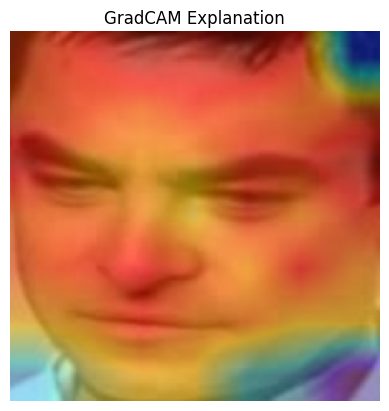

In [37]:
video="/kaggle/input/datasets/pavanikonatala/celeb-df-videos/CelebDF/Celeb-synthesis/id0_id16_0003.mp4"
read_video(video)

Extraction finished
Total faces saved: 30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Fake probability: 0.6345792412757874
Prediction: FAKE VIDEO


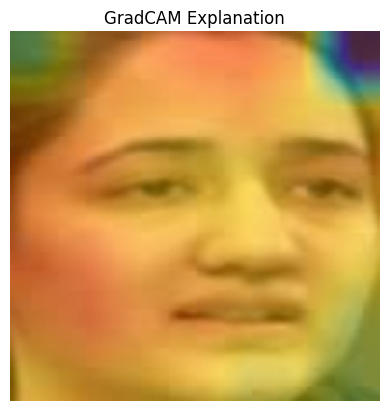

In [38]:
video="/kaggle/input/datasets/pavanikonatala/celeb-df-videos/CelebDF/YouTube-real/00262.mp4"
read_video(video)

Extraction finished
Total faces saved: 30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Fake probability: 0.12828636169433594
Prediction: REAL VIDEO


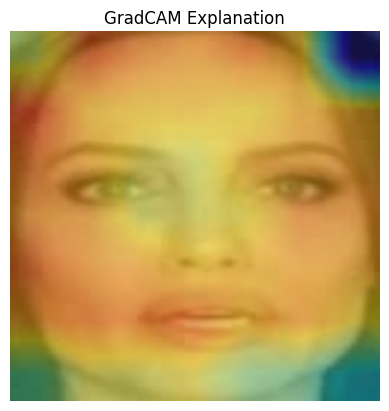

In [39]:
video="/kaggle/input/datasets/pavanikonatala/celeb-df-videos/CelebDF/Celeb-real/id13_0000.mp4"
read_video(video)

Extraction finished
Total faces saved: 30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Fake probability: 0.6908405423164368
Prediction: FAKE VIDEO


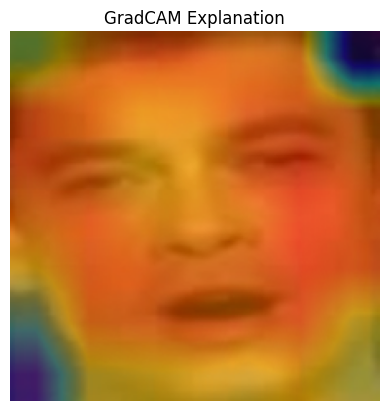

In [40]:
video="/kaggle/input/datasets/pavanikonatala/celeb-df-videos/CelebDF/Celeb-synthesis/id0_id1_0000.mp4"
read_video(video)

Extraction finished
Total faces saved: 30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Fake probability: 0.23248052597045898
Prediction: REAL VIDEO


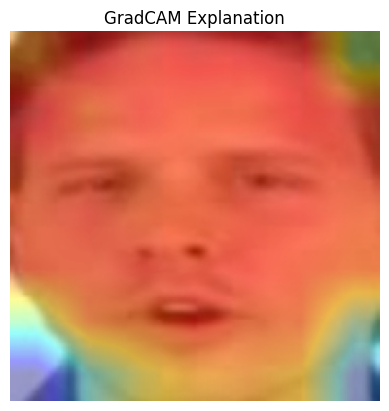

In [42]:
video="/kaggle/input/datasets/pavanikonatala/celeb-df-videos/CelebDF/YouTube-real/00272.mp4"
read_video(video)

Extraction finished
Total faces saved: 26
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Fake probability: 0.2579692304134369
Prediction: REAL VIDEO


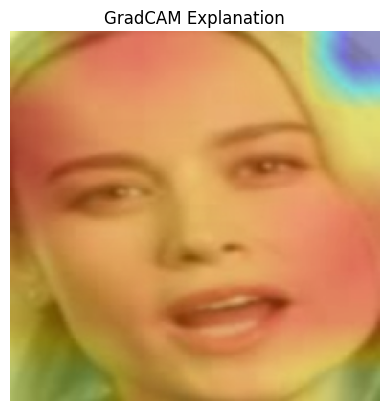

In [44]:
video="/kaggle/input/datasets/pavanikonatala/celeb-df-videos/CelebDF/YouTube-real/00267.mp4"
read_video(video)